In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('insurance.csv')

df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [3]:
pd.set_option("display.float_format","{:.2f}". format)

In [4]:
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [7]:
df.dropna(inplace = True)

In [8]:
df.describe() # you can add the argument include = "all"

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


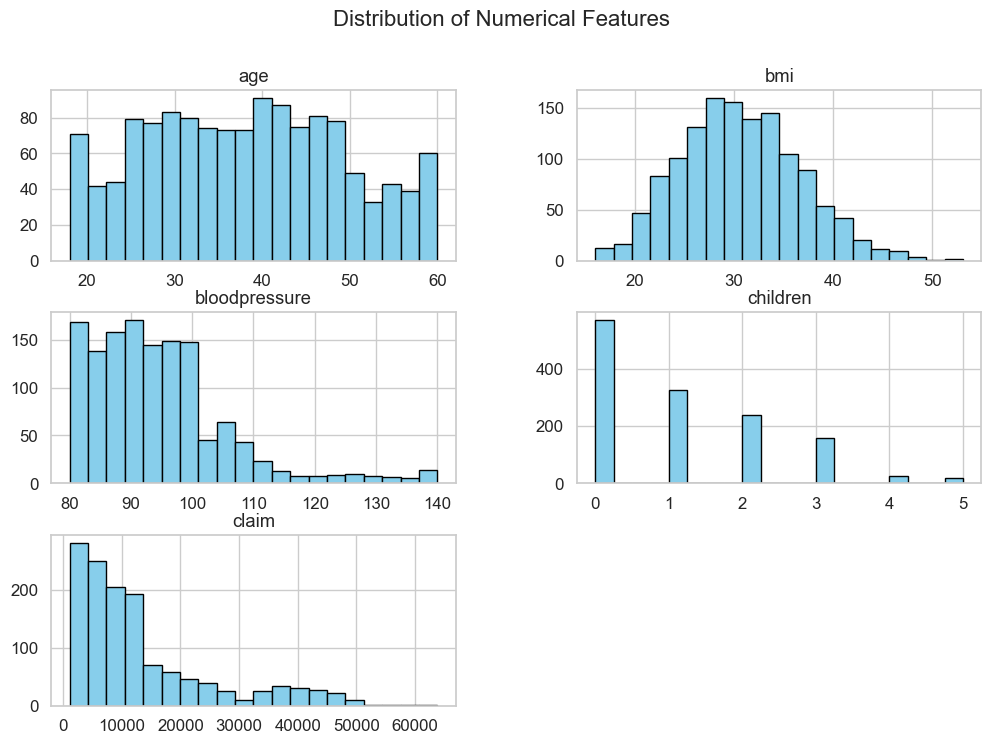

In [9]:
numeric_cols = ["age","bmi","bloodpressure","children","claim"]
df[numeric_cols].hist(bins=20, figsize=(12,8), color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

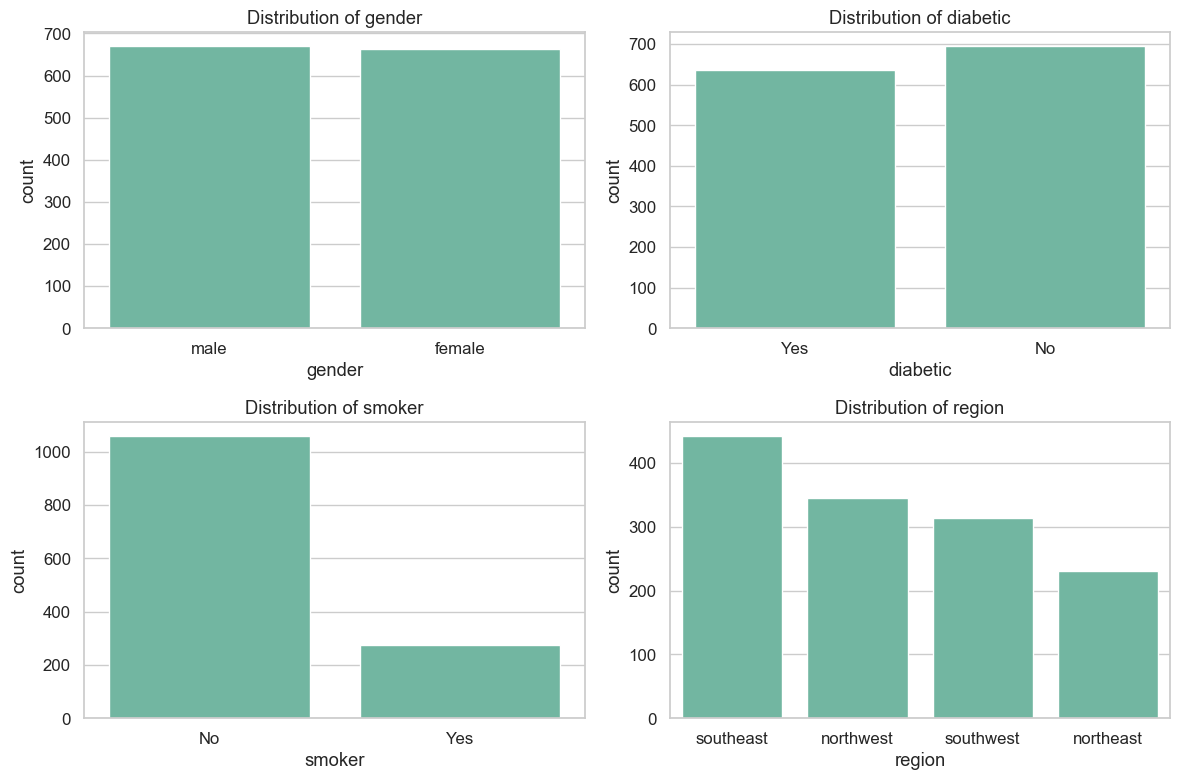

In [10]:
cat_cols = ["gender", "diabetic", "smoker", "region"]
plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2,i)
    sns.countplot(data= df, x = col)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()    

In [11]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

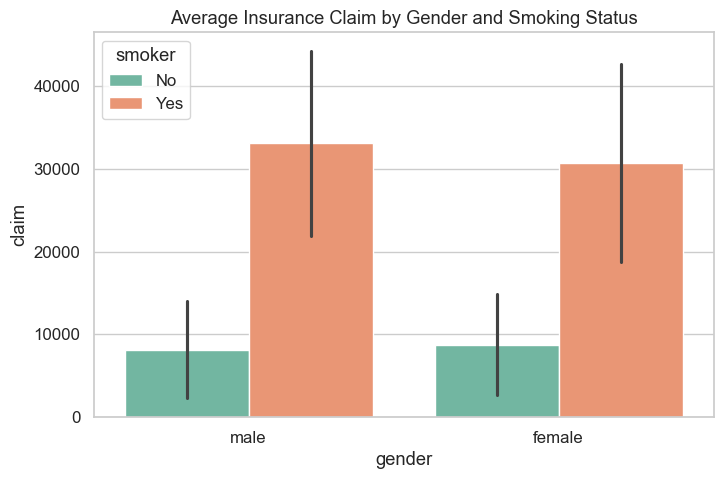

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data= df, x= "gender", y= "claim", hue="smoker", estimator= "mean", errorbar = "sd")
plt.title("Average Insurance Claim by Gender and Smoking Status")
plt.show()


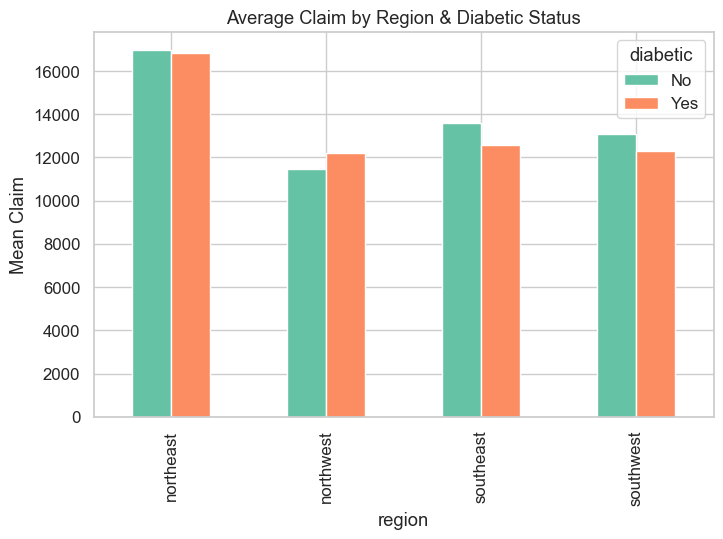

In [13]:
pivot_region_diabetic = df.groupby(["region","diabetic"])["claim"].mean().unstack()
pivot_region_diabetic.plot(kind = "bar", figsize=(8,5))
plt.title("Average Claim by Region & Diabetic Status")
plt.ylabel("Mean Claim")
plt.show()

In [14]:
pivot_region_smoker = df.groupby(["region","smoker"])["claim"].mean().unstack()
pivot_region_smoker

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


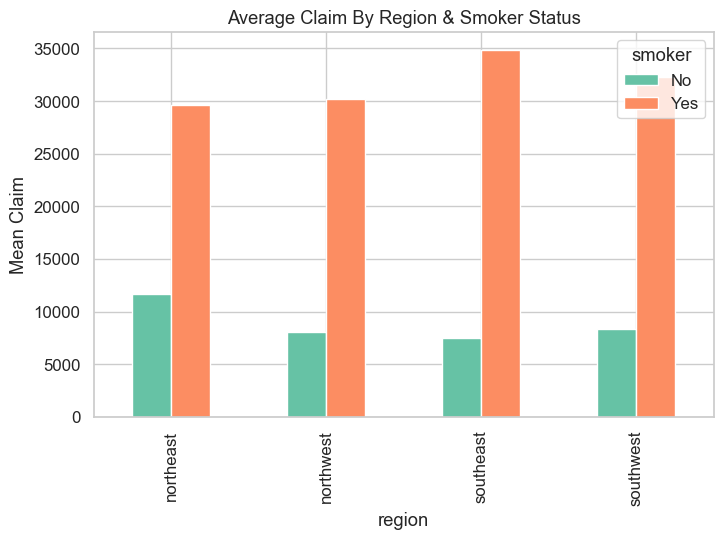

In [15]:
pivot_region_smoker.plot(kind="bar", figsize=(8,5))
plt.title("Average Claim By Region & Smoker Status")
plt.ylabel("Mean Claim")
plt.show()

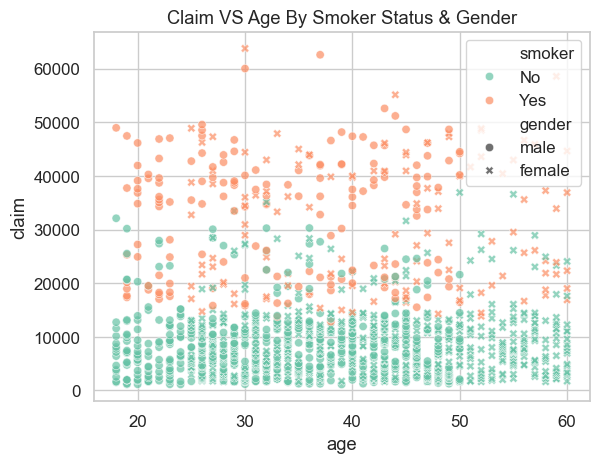

In [16]:
sns.scatterplot(data=df, x = "age", y="claim", hue="smoker", style="gender", alpha= 0.7)
plt.title("Claim VS Age By Smoker Status & Gender")
plt.show()

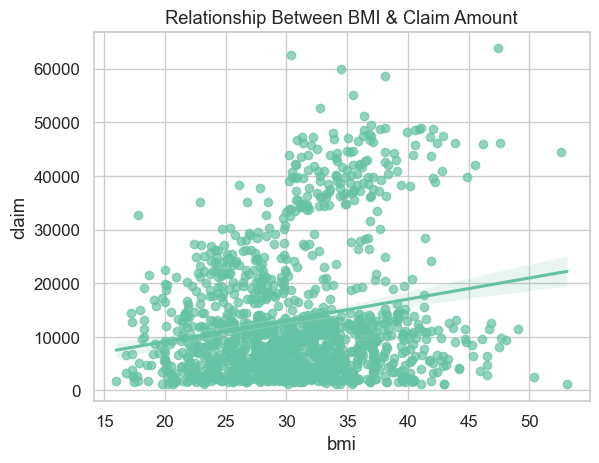

In [17]:
sns.regplot(data= df, x = "bmi", y = "claim", scatter_kws={"alpha": 0.7})
plt.title("Relationship Between BMI & Claim Amount")
plt.show()

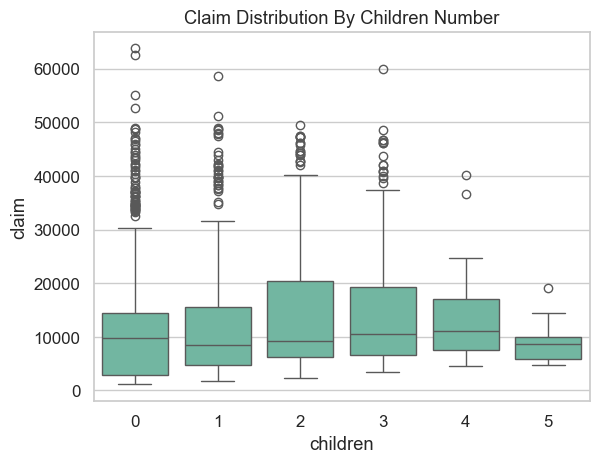

In [18]:
sns.boxplot(data = df, x = "children", y = "claim")
plt.title("Claim Distribution By Children Number")
plt.show() 

In [19]:
df["age_group"] = pd.cut(df["age"], bins = [0,18,30,45,60,100], labels = ["<18","18-30","31-45","46-60","60+"])
df["age_group"].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

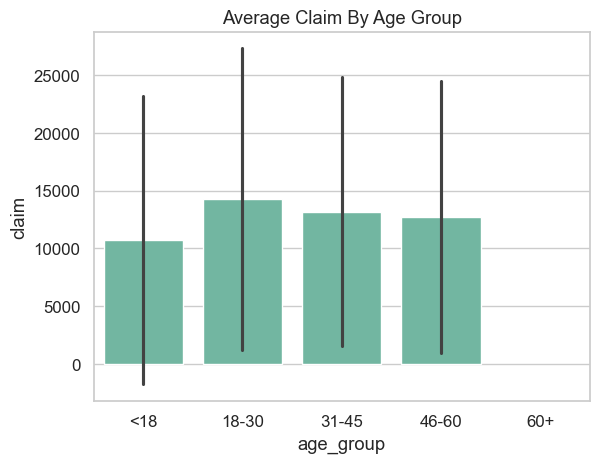

In [20]:
sns.barplot(data = df, x = "age_group", y = "claim", estimator = "mean", errorbar = "sd")
plt.title("Average Claim By Age Group")
plt.show()

In [21]:
df["bmi_category"] = pd.cut(df["bmi"], bins= [0, 18.5, 24.9, 29.9, 100], labels=["Underweight", "Normal","Overweight", "Obese"])
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

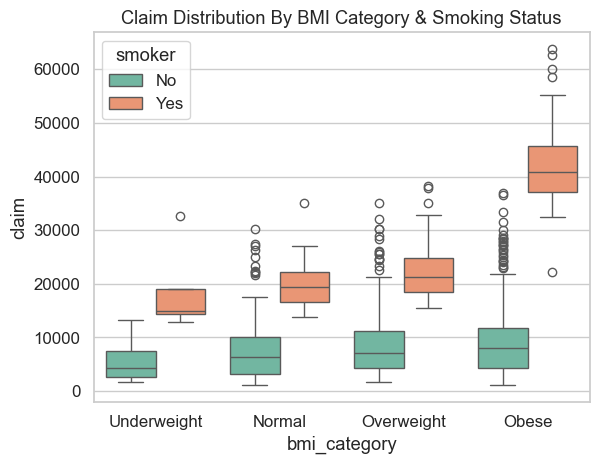

In [22]:
sns.boxplot(data = df, x = "bmi_category", y = "claim", hue = "smoker")
plt.title("Claim Distribution By BMI Category & Smoking Status")
plt.show()

In [23]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x=="Yes").mean() * 100),
    mean_claim = ("claim", "mean")
).reset_index()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [25]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [26]:
X = df[["age","gender","bmi","bloodpressure","diabetic","children","smoker"]]
y = df["claim"]

In [27]:
cat_cols = ["gender","diabetic","smoker"]
label_encorders = {}

In [28]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encorders[col] = le

    joblib.dump(le, f"label_encoder_{col}.pkl")


C:\Users\pc\AppData\Local\Temp\ipykernel_10312\466174125.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\pc\AppData\Local\Temp\ipykernel_10312\466174125.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\pc\AppData\Local\Temp\ipykernel_10312\466174125.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

In [29]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [30]:
label_encorders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [32]:
num_cols = ["age","bmi","bloodpressure","children"]
scaler = StandardScaler()

In [33]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [34]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [35]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2": r2, "MAE" : mae, "RMSE" : rmse}

results = {}


In [36]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results["Linear Regression"] = evaluate_model(lr,X_train, X_test, y_train, y_test)
print("Linear Regression model trained")

best_poly_model = None
best_poly_score = -np.inf

for degree in [2,3]:
    poly = PolynomialFeatures()
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)

    score = poly_lr.score(X_test_poly, y_test)

    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model
results[f"Polynomial Regression (deg = {degree})"] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test )

print("Polynomial regression models are trained")

rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

rf_grid = GridSearchCV(rf, rf_params, cv = 3, scoring = "r2", n_jobs =-1, verbose = 0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf,X_train, X_test, y_train, y_test)

print("Random Forest model trained, best paramaters", rf_grid.best_params_)


svr = SVR()

svr_params = {
    "kernel": ["rbf","poly","linear"],
    "C": [1, 10, 50],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2,3]
}

svr_grid = GridSearchCV(svr, svr_params, cv= 3, scoring = "r2", n_jobs = -1, verbose = 0)
svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)

print("Support Vector Regressor model trained, best parameters:", svr_grid.best_params_)

xgb = XGBRegressor(objective = "reg:squarederror")

xgb_params = {
    "n_estimators": [100,200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
best_xgb= xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)

print("XGBoost model trained, best parameters:", xgb_grid.best_params_)


Linear Regression model trained
Polynomial regression models are trained
Random Forest model trained, best paramaters {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Support Vector Regressor model trained, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost model trained, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [37]:
results

{'Linear Regression': {'R2': 0.6466014870990318,
  'MAE': np.float64(5090.867144324161),
  'RMSE': np.float64(6672.298272673933)},
 'Polynomial Regression (deg = 2)': {'R2': 0.7515832669660769,
  'MAE': np.float64(4293.482168781241),
  'RMSE': np.float64(5594.142391432412)},
 'Random Forest': {'R2': 0.7857540861244889,
  'MAE': np.float64(4015.3515806653136),
  'RMSE': np.float64(5195.165263169995)},
 'SVR': {'R2': 0.49258244765086323,
  'MAE': np.float64(5446.684970113341),
  'RMSE': np.float64(7995.135649155599)},
 'XGBoost': {'R2': 0.7953438702997466,
  'MAE': np.float64(3991.618620962079),
  'RMSE': np.float64(5077.564769379242)}}

In [38]:
results_df = pd.DataFrame(results).T.sort_values(by="R2", ascending= False)
results_df

,R2,MAE,RMSE
XGBoost,0.80,3991.62,5077.56
Random Forest,0.79,4015.35,5195.17
Polynomial Regression (deg = 2),0.75,4293.48,5594.14
Linear Regression,0.65,5090.87,6672.30
SVR,0.49,5446.68,7995.14


In [39]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [40]:
best_r2 = results_df["R2"].max()
best_r2

np.float64(0.7953438702997466)

In [41]:
top_model = results_df[results_df["R2"]== best_r2]
top_model

,R2,MAE,RMSE
XGBoost,0.80,3991.62,5077.56


In [42]:
best_model = models[top_model.index[0]]
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [43]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best model selected: {top_model.index[0]}")

Best model selected: XGBoost
